In [3]:
import tensorflow as tf
import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
DATASET_DIR = r"C:\Users\Paras\Desktop\Projects\Solar Panel Defect Classification\data"
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
SEED = 42 # A seed controls randomness

In [4]:
training_data = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [5]:
validation_data = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed =  SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [6]:
classes = training_data.class_names
classes

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [6]:
num_classes = len(classes)

### Some steps for data preparation and speed

In [7]:
# 2. Optimization: Autotune buffer size 
AUTOTUNE = tf.data.AUTOTUNE 

# 3. Apply Normalization (Rescaling 0-255 -> 0-1) 
normalization_layer = keras.layers.Rescaling(1./255) 

def preprocess(image, label): 
  return normalization_layer(image), label 

# 4. Apply optimizations to the pipeline 
train_dataset = training_data.map(preprocess).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_data.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

## Base Model

In [8]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [10]:
model1 = keras.Sequential([Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))])

# Convolution layer: 1
model1.add(Conv2D(32, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

# Convolution layer: 2
model1.add(Conv2D(64, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

# Convolution layer: 3
model1.add(Conv2D(128, (3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))

model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.5))

model1.add(Dense(num_classes, activation='softmax'))

In [11]:
model1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
EPOCHS = 10

In [ ]:
# Training the model on 10 epochs

history = model1.fit(
    train_dataset,
    validation_data= validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.2556 - loss: 1.8537 - val_accuracy: 0.1921 - val_loss: 1.7238
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 403ms/step - accuracy: 0.3842 - loss: 1.5580 - val_accuracy: 0.4068 - val_loss: 1.4573
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.4562 - loss: 1.4010 - val_accuracy: 0.4746 - val_loss: 1.4000
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 371ms/step - accuracy: 0.5508 - loss: 1.2008 - val_accuracy: 0.5480 - val_loss: 1.2491
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 361ms/step - accuracy: 0.6667 - loss: 0.9355 - val_accuracy: 0.5537 - val_loss: 1.2895
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 352ms/step - accuracy: 0.7133 - loss: 0.7960 - val_accuracy: 0.5650 - val_loss: 1.3654
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 361ms/step - accuracy: 0.8051 - loss: 0.5597 - val_accuracy: 0.5763 - val_loss: 1.3447
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 352ms/step - accuracy: 0.8814 - loss: 0.3672 - val_accuracy: 0

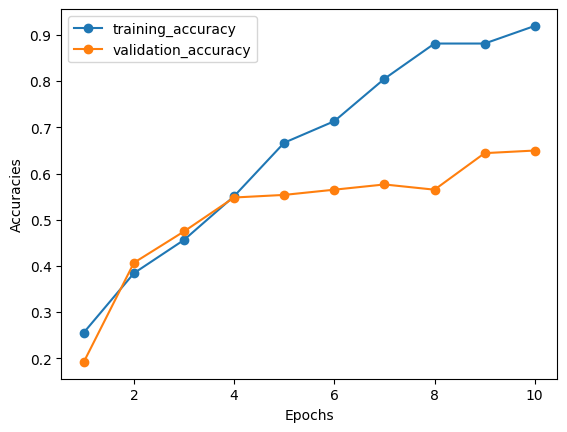

In [23]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [ ]:
EPOCHS = 20

history = model1.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 392ms/step - accuracy: 0.9421 - loss: 0.1817 - val_accuracy: 0.6328 - val_loss: 1.4746
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 428ms/step - accuracy: 0.9689 - loss: 0.1464 - val_accuracy: 0.5989 - val_loss: 1.6611
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 443ms/step - accuracy: 0.9703 - loss: 0.1156 - val_accuracy: 0.6610 - val_loss: 1.4725
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 433ms/step - accuracy: 0.9718 - loss: 0.1072 - val_accuracy: 0.6271 - val_loss: 1.7078
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 433ms/step - accuracy: 0.9590 - loss: 0.1507 - val_accuracy: 0.5819 - val_loss: 1.7896
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 434ms/step - accuracy: 0.9562 - loss: 0.1325 - val_accuracy: 0.6158 - val_loss: 1.5172
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 433ms/step - accuracy: 0.9548 - loss: 0.1356 - val_accuracy: 0.5876 - val_loss: 2.3862
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 444ms/step - accuracy: 0.9788 - loss: 0.0820 - val_accur

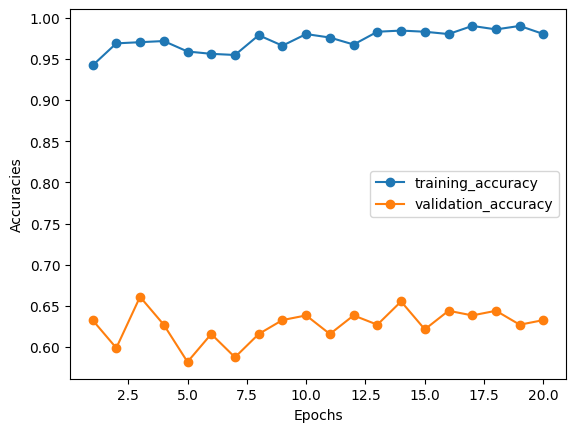

In [25]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [ ]:
# Adding augmentation layers to the model

data_augmentation = keras.Sequential([
  keras.layers.RandomFlip("horizontal_and_vertical"),
  keras.layers.RandomRotation(0.2),
  keras.layers.RandomZoom(0.2),
])

In [ ]:
# Add this as the first layer in your model
model2 = keras.Sequential([Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),data_augmentation])

# Convolution layer: 1
model2.add(Conv2D(32, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))  
# Convolution layer: 2
model2.add(Conv2D(64, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

# Convolution layer: 3
model2.add(Conv2D(128, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))

model2.add(Dense(num_classes, activation='softmax'))

In [ ]:
model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

history = model2.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 382ms/step - accuracy: 0.2500 - loss: 1.7893 - val_accuracy: 0.3559 - val_loss: 1.6061
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.3333 - loss: 1.6398 - val_accuracy: 0.2486 - val_loss: 1.8144
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 364ms/step - accuracy: 0.3503 - loss: 1.6127 - val_accuracy: 0.3616 - val_loss: 1.5309
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - accuracy: 0.3672 - loss: 1.5762 - val_accuracy: 0.3559 - val_loss: 1.5308
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 456ms/step - accuracy: 0.3969 - loss: 1.5244 - val_accuracy: 0.2316 - val_loss: 1.9294
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 451ms/step - accuracy: 0.3955 - loss: 1.4800 - val_accuracy: 0.2542 - val_loss: 2.2149
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 449ms/step - accuracy: 0.3842 - loss: 1.4928 - val_accuracy: 0.2712 - val_loss: 1.9727
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - accuracy: 0.4393 - loss: 1.4458 - val_accurac

### From here we will use pre-trained models

# Transfer Learning

## ResNet

In [13]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
])

In [14]:
# Preparing datasets with ResNet preprocessing
from keras.applications.resnet import preprocess_input
from keras.applications import ResNet50

def preprocess(image, label):
    image = preprocess_input(image)   # ResNet-specific normalization
    return image, label

train_dataset = training_data.map(preprocess).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_dataset = validation_data.map(preprocess).cache().prefetch(tf.data.AUTOTUNE)


In [15]:
base_model_res = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT,IMAGE_WIDTH,3)
)

base_model_res.trainable = False # We reuse ResNet’s learned features and freeze the base model

In [16]:
# Adding  our own classifier
res_model = keras.Sequential([
    data_augmentation,
    base_model_res,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes,activation = "softmax")
])

In [64]:
res_model.compile(optimizer="adam",loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

In [65]:
res_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [67]:
EPOCHS = 20
history = res_model.fit(train_dataset,validation_data=val_dataset,epochs=EPOCHS)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 906ms/step - accuracy: 0.5282 - loss: 1.2405 - val_accuracy: 0.5311 - val_loss: 1.1069
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 811ms/step - accuracy: 0.6229 - loss: 1.0049 - val_accuracy: 0.5593 - val_loss: 1.0452
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 885ms/step - accuracy: 0.6525 - loss: 0.9075 - val_accuracy: 0.5932 - val_loss: 1.0447
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 969ms/step - accuracy: 0.6864 - loss: 0.8472 - val_accuracy: 0.5989 - val_loss: 1.0552
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 968ms/step - accuracy: 0.7076 - loss: 0.7769 - val_accuracy: 0.6610 - val_loss: 0.8588
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 986ms/step - accuracy: 0.7331 - loss: 0.7378 - val_accuracy: 0.6554 - val_loss: 0.8711
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 987ms/step - accuracy: 0.7472 - loss: 0.6834 - val_accuracy: 0.6384 - val_loss: 0.8250
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 970ms/step - accuracy: 0.7373 - loss: 0.6927 - val_accu

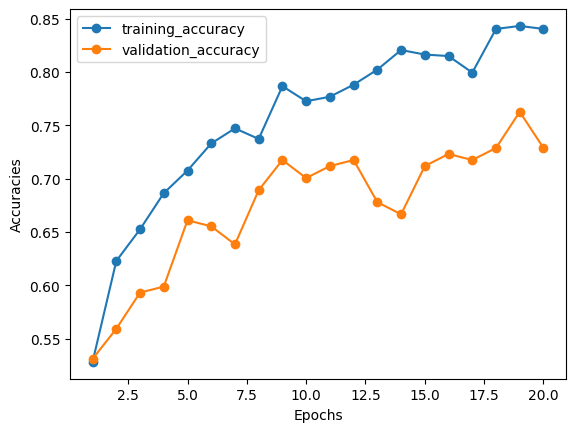

In [68]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [72]:
from keras.callbacks import EarlyStopping

base_model_res.trainable = True

for layer in base_model_res.layers[:-30]:
    layer.trainable = False

res_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

res_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6935 - loss: 0.8712 - val_accuracy: 0.7458 - val_loss: 0.6885
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.7302 - loss: 0.6910 - val_accuracy: 0.7232 - val_loss: 0.6964
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7500 - loss: 0.6389 - val_accuracy: 0.7119 - val_loss: 0.7209
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7938 - loss: 0.5537 - val_accuracy: 0.7119 - val_loss: 0.7517
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8136 - loss: 0.5076 - val_accuracy: 0.7175 - val_loss: 0.7780
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8220 - loss: 0.4705 - val_accuracy: 0.7006 - val_loss: 0.7730


### Model Evaluation

In [74]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = res_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.80      0.73      0.77        45
            Clean       0.67      0.59      0.62        34
            Dusty       0.70      0.81      0.75        43
Electrical-damage       0.52      0.75      0.62        16
  Physical-Damage       1.00      0.74      0.85        19
     Snow-Covered       0.95      0.90      0.92        20

         accuracy                           0.75       177
        macro avg       0.77      0.75      0.76       177
     weighted avg       0.76      0.75      0.75       177



[[33  4  4  3  0  1]
 [ 2 20  8  4  0  0]
 [ 6  2 35  0  0  0]
 [ 0  3  1 12  0  0]
 [ 0  1  0  4 14  0]
 [ 0  0  2  0  0 18]]


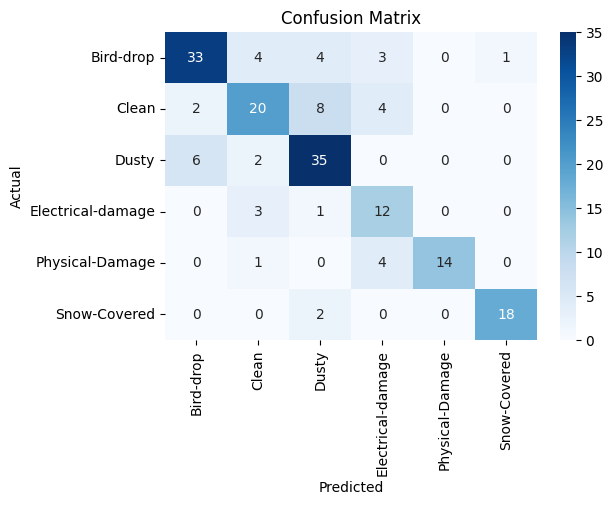

In [78]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Efficient Net

In [52]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
    ])

In [54]:
# Preparing datasets with Efficientnet preprocessing
import tensorflow as tf
from keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input

def preprocess(image, label):
    image = preprocess_input(image)  
    return image, label


train_dataset = training_data.map(preprocess).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_dataset = validation_data.map(preprocess).cache().prefetch(tf.data.AUTOTUNE)


In [55]:
base_model_eff = EfficientNetV2B0(
    weights = "imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT,IMAGE_WIDTH,3)
)

In [56]:
base_model_eff.trainable = False 

# Adding  our own classifier
effv2_model = keras.Sequential([
    data_augmentation,
    base_model_eff,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes,activation = "softmax")
])

In [57]:
effv2_model.compile(optimizer="adam",loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

In [58]:
effv2_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,919,312 (22.58 MB)

In [69]:
EPOCHS = 20
history = effv2_model.fit(
    train_dataset,
    validation_data= val_dataset,
    epochs=EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.6850 - loss: 0.8834 - val_accuracy: 0.4689 - val_loss: 1.4429
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.7429 - loss: 0.7198 - val_accuracy: 0.4972 - val_loss: 1.2979
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.7782 - loss: 0.6330 - val_accuracy: 0.4746 - val_loss: 1.4392
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - accuracy: 0.7797 - loss: 0.5944 - val_accuracy: 0.4576 - val_loss: 1.6498
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.8037 - loss: 0.5898 - val_accuracy: 0.4746 - val_loss: 1.4755
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.8178 - loss: 0.5188 - val_accuracy: 0.4689 - val_loss: 1.5825
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.8291 - loss: 0.4944 - val_accuracy: 0.4520 - val_loss: 1.7196
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.8234 - loss: 0.4681 - val_accuracy: 0.

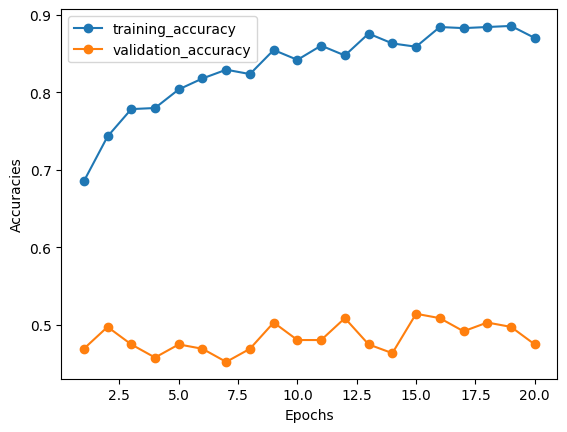

In [70]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1 , EPOCHS +1)

plt.plot(epochs,training_accuracy,label = "training_accuracy",marker = "o")
plt.plot(epochs,validation_accuracy,label = "validation_accuracy",marker = "o")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.show()

In [50]:
# effv2_model.save(r"C:\Users\Paras\Desktop\Projects\Solar Panel Defect Classification\models\effv2_model.keras")

### Fine Tuning

In [ ]:
from keras.callbacks import EarlyStopping

base_model_eff.trainable = True

for layer in base_model_eff.layers[:-30]:
    layer.trainable = False

effv2_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

effv2_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - accuracy: 0.8178 - loss: 0.5283 - val_accuracy: 0.5198 - val_loss: 1.2581
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - accuracy: 0.8206 - loss: 0.5160 - val_accuracy: 0.5367 - val_loss: 1.2299
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 0.8446 - loss: 0.4604 - val_accuracy: 0.5424 - val_loss: 1.2102
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 362ms/step - accuracy: 0.8446 - loss: 0.4843 - val_accuracy: 0.5593 - val_loss: 1.2062
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 355ms/step - accuracy: 0.8517 - loss: 0.4665 - val_accuracy: 0.5480 - val_loss: 1.2053
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 352ms/step - accuracy: 0.8333 - loss: 0.4803 - val_accuracy: 0.5537 - val_loss: 1.1921
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step - accuracy: 0.8446 - loss: 0.4793 - val_accuracy: 0.5537 - val_loss: 1.2051
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - accuracy: 0.8573 - loss: 0.4809 - val_accuracy: 0

### Model Evaluation

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = effv2_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.77      0.22      0.34        45
            Clean       0.76      0.56      0.64        34
            Dusty       0.42      0.86      0.56        43
Electrical-damage       0.48      0.81      0.60        16
  Physical-Damage       0.75      0.16      0.26        19
     Snow-Covered       0.80      0.80      0.80        20

         accuracy                           0.55       177
        macro avg       0.66      0.57      0.54       177
     weighted avg       0.66      0.55      0.52       177



[[10  0 30  4  1  0]
 [ 2 19 10  3  0  0]
 [ 0  1 37  2  0  3]
 [ 1  0  2 13  0  0]
 [ 0  3  7  5  3  1]
 [ 0  2  2  0  0 16]]


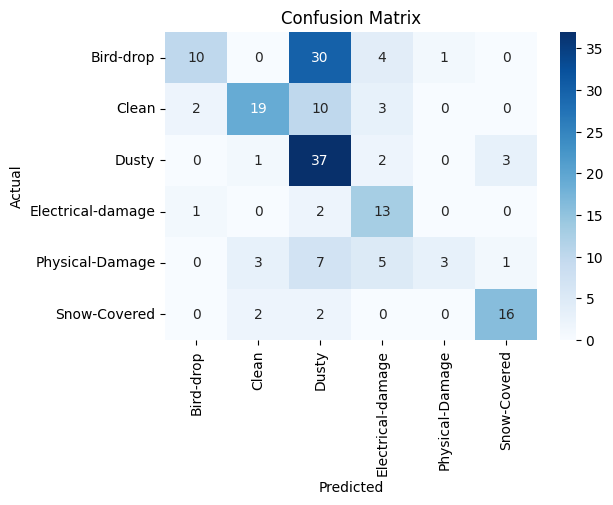

In [80]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



## Model Comparison & Results

### **ResNet50 Performance:**
- **Overall Accuracy**: 75% ✓
- **Best at**: Physical Damage (100% precision), Snow-Covered (92% F1-score)
- **Weakest at**: Electrical Damage (52% precision)

### **EfficientNetV2B0 Performance:**
- **Overall Accuracy**: 55% ✗
- **Best at**: Dusty & Electrical Damage (high recall ~81%)
- **Weakest at**: Physical Damage (only 16% recall)

---

## 📊 Error Analysis

### **ResNet50 (Better Model)**
| Class | Precision | Recall | Issue |
|-------|-----------|--------|-------|
| Bird-drop | 80% | 73% | Good overall |
| Clean | 67% | 59% | Moderate confusion |
| Dusty | 70% | 81% | Balanced |
| **Electrical-damage** | 52% | 75% | ⚠️ Often confused with Dusty |
| Physical-Damage | **100%** | 74% | Very accurate when detected |
| Snow-Covered | **95%** | 90% | ✅ Excellent |

### **EfficientNetV2B0 (Struggles)**
| Class | Precision | Recall | Issue |
|-------|-----------|--------|-------|
| **Bird-drop** | 77% | **22%** | ⚠️ Misses most of them |
| Clean | 76% | 56% | Poor recall |
| Dusty | 42% | **86%** | Predicts too much |
| Electrical-damage | 48% | 81% | Similar confusion |
| **Physical-Damage** | 75% | **16%** | ⚠️ Terrible detection |
| Snow-Covered | 80% | 80% | Decent |

---

## **WINNER: ResNet50** 

### **Why ResNet50 Won:**
1. **20% Higher Accuracy** (75% vs 55%)
2. **Better at detecting rare defects** - Catches physical damage and bird drop much better
3. **More reliable** - Fewer false negatives (missed defects)
4. **Only weak point** - Electrical damage confusion (but still catches 75% of them)

### **What EfficientNetV2B0 Got Wrong:**
- Misses **78% of Bird-drop** defects
- Misses **84% of Physical damage** 
- Overshoots on Dusty classification
- Overall accuracy drops to 55% - too many false negatives (missing real defects)

---

## **Bottom Line in Simple Words:**

**ResNet50** =  **The Clear Winner**
- Catches real defects correctly
- 20% more accurate than EfficientNet
- If you detect a problem, it's usually real

**EfficientNetV2B0** = **Not suitable for this task**
- Misses too many defects (78% of bird drops, 84% of physical damage)
- Would let broken solar panels ship to customers
- Not safe for production quality control

We will use **ResNet50** for detecting solar panel defects. The extra speed of EfficientNetV2 isn't worth missing defects that could cost money and safety.

In [83]:
res_model.save(r"C:\Users\Paras\Desktop\Projects\Solar Panel Defect Classification\models\res_model_final.keras")

### Hyperparameter Optimization (HPO) - ResNet50 with Randomized Search

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# 1. Extract labels from training_data object
# training_data is the Raw dataset before mapping/caching
y_train = np.concatenate([y for x, y in training_data], axis=0)

# 2. Calculate weights
# 'balanced' mode automatically calculates weights inversely proportional to class frequencies
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Create a dictionary for Keras
class_weight_dict = dict(enumerate(weights))

print("Calculated Class Weights:", class_weight_dict)
for i, weight in class_weight_dict.items():
    print(f"Class {training_data.class_names[i]}: {weight:.2f}")

Calculated Class Weights: {0: np.float64(0.7283950617283951), 1: np.float64(0.7421383647798742), 2: np.float64(0.8027210884353742), 3: np.float64(1.3563218390804597), 4: np.float64(2.36), 5: np.float64(1.145631067961165)}
Class Bird-drop: 0.73
Class Clean: 0.74
Class Dusty: 0.80
Class Electrical-damage: 1.36
Class Physical-Damage: 2.36
Class Snow-Covered: 1.15


In [ ]:
import keras_tuner as kt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input

def build_resnet_hypermodel(hp):
    # Base model: ResNet50 (Weights are frozen initially)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False 

    model = keras.Sequential([
        # Data Augmentation (Using existing layers)
        keras.Sequential([
            keras.layers.RandomFlip("horizontal"),
            keras.layers.RandomRotation(0.05),
            keras.layers.RandomZoom(0.05),
        ]),
        keras.layers.Lambda(preprocess_input),
        base_model,
        keras.layers.GlobalAveragePooling2D(),
        
        # Hyperparameter: Number of units in the first Dense layer
        keras.layers.Dense(
            units=hp.Int('dense_units', min_value=128, max_value=512, step=128),
            activation='relu'
        ),
        
        # Hyperparameter: Dropout rate
        keras.layers.Dropout(
            rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
        ),
        
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Hyperparameter: Learning rate
    lr = hp.Float('learning_rate', min_value=1e-5, max_value=3e-4, sampling='log')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [42]:
# Initialize the Tuner
tuner = kt.RandomSearch(
    build_resnet_hypermodel,
    objective='val_accuracy',
    max_trials=10, # Number of different combinations to try
    executions_per_trial=1,
    directory='solar_defect_tuning',
    project_name='resnet50_random_search',
    seed=42
)

# Run the search
tuner.search(
    train_dataset, 
    validation_data=val_dataset, 
    class_weight = class_weight_dict,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)]
)

# Get the best hyperparameters and model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Dense Units:", best_hps.get('dense_units'))
print("Best Dropout:", best_hps.get('dropout'))
print("Best Learning Rate:", best_hps.get('learning_rate'))

best_model = tuner.get_best_models()[0]

Trial 10 Complete [00h 03m 25s]
val_accuracy: 0.7118644118309021

Best val_accuracy So Far: 0.8192090392112732
Total elapsed time: 00h 38m 11s
Best Dense Units: 512
Best Dropout: 0.2
Best Learning Rate: 0.00026716512320126124


c:\Users\Paras\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [43]:
best_model.save(r"C:\Users\Paras\Desktop\Projects\Solar Panel Defect Classification\models\best_model_final.keras")

In [44]:
best_model.evaluate(val_dataset)

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 615ms/step - accuracy: 0.8192 - loss: 0.5937


[0.5937160849571228, 0.8192090392112732]

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = best_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.75      0.98      0.85        45
            Clean       0.81      0.85      0.83        34
            Dusty       0.83      0.56      0.67        43
Electrical-damage       0.92      0.75      0.83        16
  Physical-Damage       0.90      0.95      0.92        19
     Snow-Covered       0.90      0.90      0.90        20

         accuracy                           0.82       177
        macro avg       0.85      0.83      0.83       177
     weighted avg       0.83      0.82      0.81       177



[[44  0  0  0  1  0]
 [ 1 29  4  0  0  0]
 [10  7 24  0  1  1]
 [ 3  0  0 12  0  1]
 [ 0  0  0  1 18  0]
 [ 1  0  1  0  0 18]]


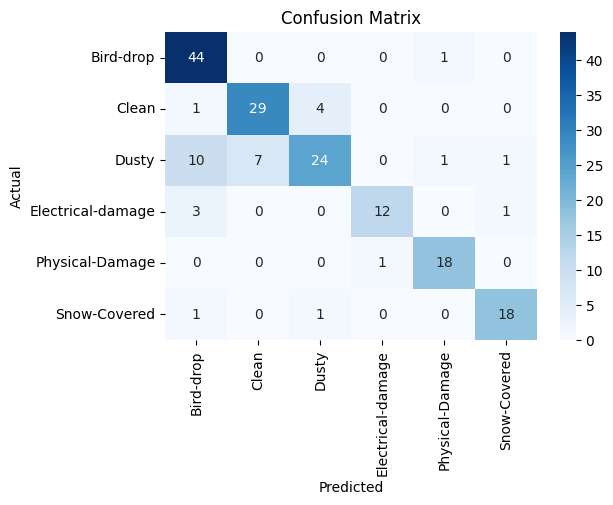

In [47]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Hyperparameter optimization and class-weighting significantly improved recall for rare defect classes. The final model prioritizes safety-critical defects such as Physical-Damage, achieving 95% recall, even at the cost of minor ambiguity among non-critical surface defects.

### Fine Tuning the best model

In [34]:
best_model.trainable = True

for layer in best_model.layers[:-30]:
    layer.trainable = False

best_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9124 - loss: 0.3081 - val_accuracy: 0.7458 - val_loss: 0.6183
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9223 - loss: 0.2903 - val_accuracy: 0.7627 - val_loss: 0.6164
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9195 - loss: 0.2754 - val_accuracy: 0.7740 - val_loss: 0.6097
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9266 - loss: 0.2791 - val_accuracy: 0.7627 - val_loss: 0.6220
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9223 - loss: 0.2883 - val_accuracy: 0.7684 - val_loss: 0.6274
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 973ms/step - accuracy: 0.9153 - loss: 0.2633 - val_accuracy: 0.7684 - val_loss: 0.6512
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 820ms/step - accuracy: 0.9266 - loss: 0.2637 - val_accuracy: 0.7627 - val_loss: 0.6422
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 835ms/step - accuracy: 0.9153 - loss: 0.2727 - val_accuracy: 0.7627 - 

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = best_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                   precision    recall  f1-score   support

        Bird-drop       0.82      0.80      0.81        45
            Clean       0.54      0.91      0.68        34
            Dusty       0.88      0.65      0.75        43
Electrical-damage       1.00      0.69      0.81        16
  Physical-Damage       0.93      0.74      0.82        19
     Snow-Covered       0.94      0.85      0.89        20

         accuracy                           0.77       177
        macro avg       0.85      0.77      0.80       177
     weighted avg       0.82      0.77      0.78       177



[[36  8  0  0  1  0]
 [ 1 31  2  0  0  0]
 [ 5 10 28  0  0  0]
 [ 1  3  0 11  0  1]
 [ 1  4  0  0 14  0]
 [ 0  1  2  0  0 17]]


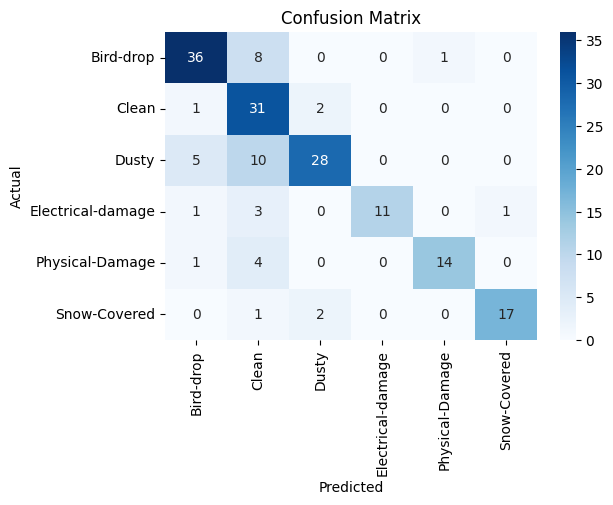

In [36]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### After hyperparameter optimization, the model achieved strong macro-F1 and high recall on rare defect classes. Fine-tuning the backbone reduced performance due to dataset size and class imbalance, so I retained the pre-fine-tuned model as it generalized better.